<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/ETF_SwingTrading_BackTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta
!pip install --upgrade backtrader

In [44]:
import yfinance as yf
import pandas as pd
import numpy as np
import logging
import backtrader as bt
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.optimize import minimize
from scipy.stats import zscore

%matplotlib inline
print("Libraries Installed!")

Libraries Installed!


## Create Class for Backtesting

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********


Initial Portfolio Value: 10000
Skipping: 2023-01-03 (Not enough data)
Skipping: 2023-01-04 (Not enough data)
Skipping: 2023-01-05 (Not enough data)
Skipping: 2023-01-06 (Not enough data)
Skipping: 2023-01-09 (Not enough data)
Skipping: 2023-01-10 (Not enough data)
Skipping: 2023-01-11 (Not enough data)
Skipping: 2023-01-12 (Not enough data)
Skipping: 2023-01-13 (Not enough data)
Skipping: 2023-01-17 (Not enough data)
Skipping: 2023-01-18 (Not enough data)
Skipping: 2023-01-19 (Not enough data)
Skipping: 2023-01-20 (Not enough data)
Skipping: 2023-01-23 (Not enough data)
Skipping: 2023-01-24 (Not enough data)
Skipping: 2023-01-25 (Not enough data)
Skipping: 2023-01-26 (Not enough data)
Skipping: 2023-01-27 (Not enough data)
Skipping: 2023-01-30 (Not enough data)
Skipping: 2023-01-31 (Not enough data)
Skipping: 2023-02-01 (Not enough data)
Skipping: 2023-02-02 (Not enough data)
Skipping: 2023-02-03 (Not enough data)
Skipping: 2023-02-06 (Not enough data)
Skipping: 2023-02-07 (Not enough

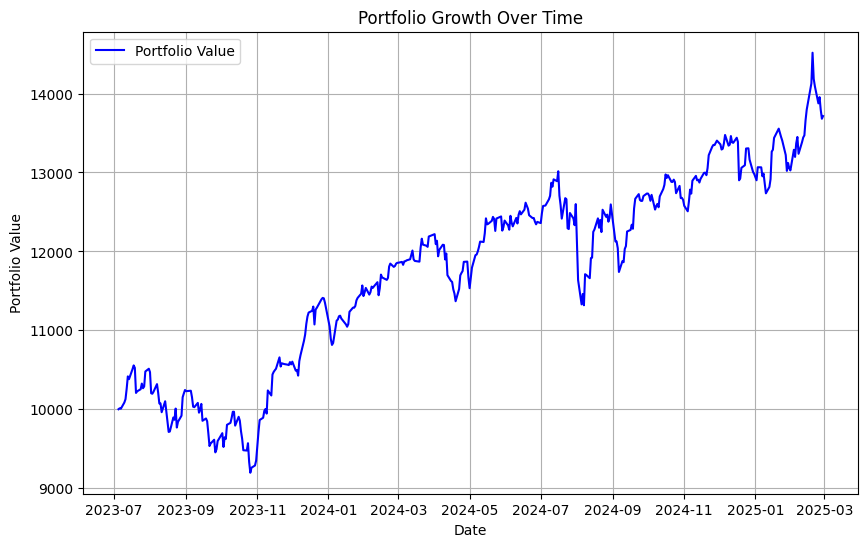

In [66]:
from mmap import ALLOCATIONGRANULARITY
import backtrader as bt
import pandas as pd

# Define the ETFRotationStrategy class with the required methods
class ETFRotationStrategy(bt.Strategy):
    top_n = 3 # Number of top ETFs to select and allocate equally
    rebalance_interval = 63 # ~21 trading days for a monthly rebalance

    def __init__(self):
        self.last_rebalance = None
        self.top_etfs = []
        self.initial_value = None
        self.ema8 = {data._name: bt.indicators.EMA(data.close, period=20) for data in self.datas}
        self.ema13 = {data._name: bt.indicators.EMA(data.close, period=50) for data in self.datas}
        self.sma = bt.indicators.SimpleMovingAverage(self.data.close, period=26)
        self.crossover = bt.indicators.CrossOver(self.data.close, self.sma)
        self.portfolio_values = []  # Store portfolio values over time
        self.min_bars = 13 * 4  # Example: Require 13 weeks (~3 months) of data

    def prenext(self):
      """ Runs before enough bars exist for all indicators. """
      print(f"Skipping: {self.datetime.date()} (Not enough data)")
      pass  # Do nothing

    def start(self):
      # Set the initial portfolio value
      self.initial_value = self.broker.get_value()
      print(f"\nInitial Portfolio Value: {self.initial_value}")

    def getdatabyname(self, ticker):
        """Find the corresponding data feed for the given ticker."""
        try:
            for data in self.datas:
                if data._name == ticker:
                    return data
        except Exception as e:
            print(f"Error getting data for {ticker}: {e}")
        return None

    def calculate_normalized_score(self, ticker):
        """Calculate normalized score using 1W, 1M, 3M performance."""
        try:
            data = self.getdatabyname(ticker)
            if data is None:
                print(f"No data found for {ticker}")
                return None
            if len(data) < 126:
                print(f"Not enough data for {data._name}")
                return None

            # Retrieve the historical close prices
            close_1w = data.close.get(size=5)
            close_1m = data.close.get(size=21)
            close_3m = data.close.get(size=63)
            close_6m = data.close.get(size=126)

             # Ensure sufficient data is returned
            if len(close_1w) < 5 or len(close_1m) < 21 or len(close_3m) < 63 or len(close_6m) <126 :
              print(f"Not enough data to calculate z-scores for {data._name}")
              return None

            # Calculate raw performance
            perf_1w = (close_1w[-1] / close_1w[0]) - 1
            perf_1m = (close_1m[-1] / close_1m[0]) - 1
            perf_3m = (close_3m[-1] / close_3m[0]) - 1
            perf_6m = (close_6m[-1] / close_6m[0]) - 1


            # Convert to numpy arrays for easier calculation
            perf_1w_np = np.array(perf_1w)
            perf_1m_np = np.array(perf_1m)
            perf_3m_np = np.array(perf_3m)

            # Calculate z-scores using numpy
            mean_1w, std_1w = np.mean(perf_1w_np), np.std(perf_1w_np)
            mean_1m, std_1m = np.mean(perf_1m_np), np.std(perf_1m_np)
            mean_3m, std_3m = np.mean(perf_3m_np), np.std(perf_3m_np)


            # Avoid deivision by zero
            std_1w = std_1w if std_1w > 0 else 1e-10
            std_1m = std_1m if std_1m > 0 else 1e-10
            std_3m = std_3m if std_3m > 0 else 1e-10


            # Compute the zscore
            zscore_1w = (perf_1w - mean_1w) / std_1w
            zscore_1m = (perf_1m - mean_1m) / std_1m
            zscore_3m = (perf_3m - mean_3m) / std_3m

            score = 0.0 * perf_1w + 0.33 * perf_1m + 0.33* perf_3m + 0.33* perf_6m
            #score = 0.05 * perf_1w + 0.8 * perf_1m + 0.15* perf_3m
            return score
        except Exception as e:
            print(f"Error calculating score for {ticker}: {e}")
            return None
        print(f"Error in rebalance_portfolio: {e}")

    def rebalance_portfolio(self):
      try:
          print("Rebalance portfolio called.")  # Log method call

          # Close existing positions
          for data in self.datas:
            position = self.getposition(data)
            print(f"Checking position for {data._name}: {position.size} shares")  # Debug position size
            if position.size > 0:
                self.close(data)
                print(f"Closed position for {data._name}")

          # Get the current portfolio value
          portfolio_value = self.broker.getvalue()
          print(f"Current portfolio value: {portfolio_value:.2f}")

          # Allocate portfolio equally among top ETFs
          allocation = portfolio_value / len(self.top_etfs)
          print(f"Allocation per ETF: {allocation:.2f}")

          for ticker in self.top_etfs:
            data = self.getdatabyname(ticker)
            if data:
                price = data.close[0]
                if price > 0:
                    shares = int(allocation / price)
                    self.buy(data=data, size=shares)
                    print(f"Bought {shares} shares of {ticker} at {price:.2f}")
                else:
                    print(f"Skipping {ticker} due to invalid price: {price}")
            else:
                print(f"No data feed found for {ticker}. Skipping.")
      except Exception as e:
        print(f"Error in rebalance_portfolio: {e}")

    def stop(self):
      """ Stop method """
      try:
        # Calculate the final portfolio value
        final_value = self.broker.get_value()

        # Ensure initial portfolio value is stored
        if not hasattr(self, 'initial_value'):
          print("Error: Initial portfolio value not set!")
          return

        # Calculate the growth percentage
        growth_percentage = ((final_value - self.initial_value) / self.initial_value) * 100

        # Display the results
        print(f"Initial Portfolio Value: {self.initial_value:.2f}")
        print(f"Final Portfolio Value: {final_value:.2f}")
        print(f"Portfolio Growth: {growth_percentage:.2f}%")

        # Plot the portfolio growth
        dates, values = zip(*self.portfolio_values)  # Unpack dates and values
        plt.figure(figsize=(10, 6))
        plt.plot(dates, values, label='Portfolio Value', color='blue')
        plt.xlabel('Date')
        plt.ylabel('Portfolio Value')
        plt.title('Portfolio Growth Over Time')
        plt.legend()
        plt.grid()
        plt.show()

      except Exception as e:
        print(f"Error in stop: {e}")

    def next(self):
      try:
        # Debugging: Print available data names to check if they are strings or tuples
        #print("Available data names:", self.getdatanames())

        # Skip the warm-up period (first 63 trading days)
        if len(self.datas[0]) <126:
          return # Do nothing until enough data is available

        # Record the initial value at the start of the backtest
        #if self.initial_value is None:
            #self.initial_value = self.broker.get_value()

        # Record the portfolio value at each step
        current_value = self.broker.getvalue()
        self.portfolio_values.append((self.datetime.date(), current_value))

         # Stop loss: Check for EMA cross and close positions if 8 EMA crosses below 13 EMA
        for data in self.datas:
            if len(data) < 13:  # Skip until enough bars exist
                continue

            position = self.getposition(data)

            ema8 = self.ema8.get(data._name, None)  # Ensure key exists
            ema13 = self.ema13.get(data._name, None)

            if ema8 is None or ema13 is None:
                continue  # Skip if EMA is not available

            ema8_value = ema8[0] if ema8[0] is not None else float('inf')  # Handle None gracefully
            ema13_value = ema13[0] if ema13[0] is not None else float('-inf')

            # Sell condition  here
            #if position.size > 0 and ema8_value < ema13_value:
                #self.close(data)
                #print(f"Stopped out of {data._name} due to 8 EMA crossing below 13 EMA")

            # Sell if price falls below SMA
            if position.size > 0 and self.crossover < 0 and self.position:
              self.close(data)
              print(f"Stopped out of {data._name} due to price crossing below 26 EMA")

        # Rebalance portfolo every INTERVAL
        if self.last_rebalance is None or (self.datetime.date() - self.last_rebalance).days >= self.rebalance_interval:
          self.last_rebalance = self.datetime.date()

          # Get the performance for each ETF
          etf_scores =[(data._name, self.calculate_normalized_score(data._name))
                for data in self.datas ]
          # sort ETFs by score in descending order and select top_m

          self.top_etfs = [
                ticker for ticker, score in sorted(etf_scores, key=lambda x: x[1], reverse=True)[:self.top_n]
            ]
          # Log the top ETFs
          print(f"\nTop {self.top_n} ETFs as of {self.datetime.date()}: {self.top_etfs}")
          self.rebalance_portfolio()
      except Exception as e:
        print(f"Error in next(): {e}")

# Function to set up and run the test
def run_test():
    cerebro = bt.Cerebro()
    # Set up the broker (optional but recommended)
    cerebro.broker.set_cash(10000)  # Starting cash for the backtest
    cerebro.broker.setcommission(commission=0.)  # Commission per trade
    # Set the position size to overide default sizing i.e. The number of units bought = cash available / asset price
    #cerebro.addsizer(bt.sizers.FixedSize, stake=100)

    # Create dummy data for two ETFs
    tickers = ['SPY', 'QQQ', 'DIA', 'IWM', 'XLK', 'XLF', 'XLY', 'XLP', 'XLU', 'XLV','IYG', 'EWH', 'VGK', 'EWO', 'UNG','FEZ','SOXX']
    for ticker in tickers:
        df =  yf.download(ticker, start='2023-01-01', end='2025-03-01')
        df.columns = df.columns.droplevel(1)  # Drop the ticker symbol from column names
        data = bt.feeds.PandasData(dataname=df, name=ticker)
        cerebro.adddata(data)

    # Add the strategy to Cerebro
    cerebro.addstrategy(ETFRotationStrategy)

    #Run the Cerebro engine to trigger the `next` method
    cerebro.run()

    # Run the Cerebro engine to trigger the `next` method and retrieve the strategy instance
    #strategies = cerebro.run()  # This returns a tuple of strategy instances
    #strategy = strategies[0]  # Access the first strategy instance

    # Test `calculate_normalized_score` on the ETF list
    #for ticker in tickers:
        #score = strategy.calculate_normalized_score(ticker)
        #print(f"Calculated normalized score for {ticker}: {score}")


# Execute the test
if __name__ == "__main__":
    run_test()





[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********


Initial Portfolio Value: 10000
Skipping: 2023-10-02 (Not enough data)
Skipping: 2023-10-03 (Not enough data)
Skipping: 2023-10-04 (Not enough data)
Skipping: 2023-10-05 (Not enough data)
Skipping: 2023-10-06 (Not enough data)
Skipping: 2023-10-09 (Not enough data)
Skipping: 2023-10-10 (Not enough data)
Skipping: 2023-10-11 (Not enough data)
Skipping: 2023-10-12 (Not enough data)
Skipping: 2023-10-13 (Not enough data)
Skipping: 2023-10-16 (Not enough data)
Skipping: 2023-10-17 (Not enough data)
Skipping: 2023-10-18 (Not enough data)
Skipping: 2023-10-19 (Not enough data)
Skipping: 2023-10-20 (Not enough data)
Skipping: 2023-10-23 (Not enough data)
Skipping: 2023-10-24 (Not enough data)
Skipping: 2023-10-25 (Not enough data)
Skipping: 2023-10-26 (Not enough data)
Skipping: 2023-10-27 (Not enough data)
Skipping: 2023-10-30 (Not enough data)
Skipping: 2023-10-31 (Not enough data)
Skipping: 2023-11-01 (Not enough data)
Skipping: 2023-11-02 (Not enough data)
Skipping: 2023-11-03 (Not enough

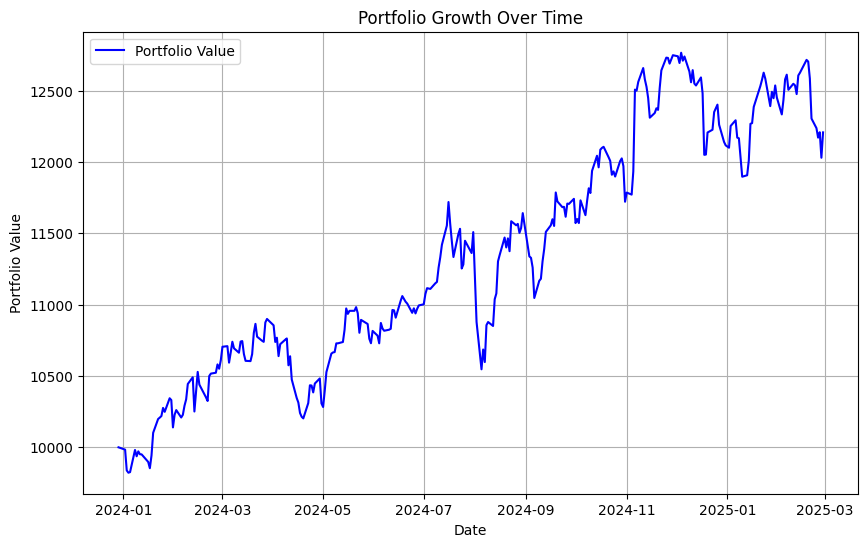

Calculated normalized score for IWM: 0.0
Calculated normalized score for XLK: 0.0
Calculated normalized score for XLF: 0.0
Calculated normalized score for XLY: 0.0
Calculated normalized score for XLP: 0.0
Calculated normalized score for XLU: 0.0
Calculated normalized score for XLV: 0.0
Calculated normalized score for IYG: 0.0
Calculated normalized score for EWH: 0.0
Calculated normalized score for VGK: 0.0
Calculated normalized score for EWO: 0.0
Calculated normalized score for UNG: 0.0
Calculated normalized score for FEZ: 0.0
Calculated normalized score for SOXX: 0.0
Calculated normalized score for SQQQ: 0.0
Calculated normalized score for SH: 0.0


In [46]:
def next(self):
      try:

        if len(self.data) < self.min_bars:
          return

        # Stop loss: Check for EMA cross and close positions if 8 EMA crosses below 13 EMA
        for data in self.datas:
            if len(data) < 13:  # Skip until enough bars exist
                continue

            position = self.getposition(data)

            ema8 = self.ema8.get(data._name, None)  # Ensure key exists
            ema13 = self.ema13.get(data._name, None)

            if ema8 is None or ema13 is None:
                continue  # Skip if EMA is not available

            ema8_value = ema8[0] if ema8[0] is not None else float('inf')  # Handle None gracefully
            ema13_value = ema13[0] if ema13[0] is not None else float('-inf')

            # Sell condition  here
            #if position.size > 0 and ema8_value < ema13_value:
                #self.close(data)
                #print(f"Stopped out of {data._name} due to 8 EMA crossing below 13 EMA")

            # Sell if price falls below SMA
            if position.size > 0 and self.crossover < 0 and self.position:
              self.close(data)
              print(f"Stopped out of {data._name} due to price crossing below 26 EMA")



        # Record the portfolio value at each step
        current_value = self.broker.getvalue()
        self.portfolio_values.append((self.datetime.date(), current_value))

         # 🔄 Rebalancing Logic: Runs on the first trading day of each month
        current_date = self.datetime.date(0)  # Get current date

        # Rebalancing logic
        if self.last_rebalance is None or current_date.month != self.last_rebalance.month:
            self.last_rebalance = self.datetime.date()

            # Get the performance for each ETF
            etf_scores = [(data._name, self.calculate_normalized_score(data._name)) for data in self.datas]

            # Sort ETFs by score in descending order and select top_n
            self.top_etfs = [ticker for ticker, score in sorted(etf_scores, key=lambda x: x[1], reverse=True)[:self.top_n]]

            # Log the top ETFs
            print(f"\nTop {self.top_n} ETFs as of {self.datetime.date()}: {self.top_etfs}")
            self.rebalance_portfolio()
      except Exception as e:
        print(f"Error in next(): {e}")


# Function to set up and run the test
def run_test():
    cerebro = bt.Cerebro()
    # Set up the broker (optional but recommended)
    cerebro.broker.set_cash(10000)  # Starting cash for the backtest
    cerebro.broker.setcommission(commission=0.)  # Commission per trade
    # Set the position size to overide default sizing i.e. The number of units bought = cash available / asset price
    #cerebro.addsizer(bt.sizers.FixedSize, stake=100)

    # Create dummy data for two ETFs
    tickers = [ 'IWM', 'XLK', 'XLF', 'XLY', 'XLP', 'XLU', 'XLV','IYG', 'EWH', 'VGK', 'EWO', 'UNG','FEZ','SOXX','SQQQ', 'SH']
    for ticker in tickers:
        df =  yf.download(ticker, start='2023-10-01', end='2025-03-01',auto_adjust=False)
        df.columns = df.columns.droplevel(1)  # Drop the ticker symbol from column names
        data = bt.feeds.PandasData(dataname=df, name=ticker)
        cerebro.adddata(data)

    # Add the strategy to Cerebro
    cerebro.addstrategy(ETFRotationStrategy)

    #Run the Cerebro engine to trigger the `next` method
    #cerebro.run()

    # Run the Cerebro engine to trigger the `next` method and retrieve the strategy instance
    strategies = cerebro.run()  # This returns a tuple of strategy instances
    strategy = strategies[0]  # Access the first strategy instance

    # Test `calculate_normalized_score` on the ETF list
    for ticker in tickers:
        score = strategy.calculate_normalized_score(ticker)
        print(f"Calculated normalized score for {ticker}: {score}")


# Execute the test
if __name__ == "__main__":
    run_test()
